# LeetCode Practice

Notebook for technical assessment coding practice.

In [ ]:
def group_anagrams(strs):
    groups = {}

    for word in strs:
        key = "".join(sorted(word))
        if key not in groups:
            groups[key] = []
        groups[key].append(word)

    return list(groups.values())


strs = ["act", "pots", "tops", "cat", "stop", "hat"]
group_anagrams(strs)


In [ ]:
def top_k_frequent(nums, k):
    counts = {}

    for num in nums:
        if num not in counts:
            counts[num] = 0
        counts[num] += 1

    items = []
    for num in counts:
        items.append([counts[num], num])

    items.sort(reverse=True)

    result = []
    for i in range(k):
        result.append(items[i][1])

    return result


nums = [1, 1, 1, 2, 2, 3]
k = 2
top_k_frequent(nums, k)


In [ ]:
def is_palindrome(s):
    cleaned = ""

    for char in s:
        if char.isalnum():
            cleaned += char.lower()

    return cleaned == cleaned[::-1]


s = "A man, a plan, a canal: Panama"
is_palindrome(s)


In [ ]:
def two_sum_sorted(numbers, target):
    left = 0
    right = len(numbers) - 1

    while left < right:
        total = numbers[left] + numbers[right]

        if total == target:
            return [left + 1, right + 1]
        if total < target:
            left += 1
        else:
            right -= 1


numbers = [1, 2, 3, 4]
target = 3
two_sum_sorted(numbers, target)


In [22]:
from scipy import integrate

def f(x):
    return x**2

result, error = integrate.quad(f, 0, 1)
print(result)


0.3333333333333333


In [23]:
def max_product(nums, k):
    max_product = 1
    for i in range(k):
        max_product *= nums[i]
    current_product = max_product
    for i in range(len(nums) - k):
        if nums[i] != 0:
            current_product /= nums[i]
        else:
            pass
        current_product *= nums[i+k]

        if current_product > max_product:
            max_product = current_product
    return max_product

max_product([1, 4, 1, 6, -3, 3, -5, 2, 26], 4)

270.0

In [29]:
def target_sum(nums, target):
    current_sum = 0
    left = 0
    for right in range(len(nums)):
        current_sum += nums[right]
        while current_sum > target:
            current_sum -= nums[left]
            left += 1
        if current_sum == target:
            return [left, right]         
target_sum([3, 1, 4, 9, 2, 1, 7, 5], 10)


[4, 6]

In [31]:
def longest_sum(nums, target):
    current_sum = 0
    count = 0
    left = 0
    best_left = 0
    best_right = 0

    for right in range(len(nums)):
        current_sum += nums[right]
        while current_sum > target:
            current_sum -= nums[left]
            left += 1
        if current_sum == target:
            if right - left + 1 > count:
                count = right - left + 1
                best_left = left
                best_right = right

    return [best_left, best_right]

longest_sum([3, 1, 4, 9, 2, 1, 7, 5], 10)

[4, 6]

In [38]:
def longest_sub_string(s):
    count = 0
    d = {}
    left = 0
    for right in range(len(s)):
        d[s[right]] = d.get(s[right], 0) + 1
        while d[s[right]] > 1 and left <= right:
                d[s[left]] -= 1
                left += 1
        count = max(count, right - left + 1)
        
    return count

longest_sub_string("aabaaaaaacdbbbdertsaaavder")

7

In [52]:
def max_string(L):
    left = 0
    best_left = 0
    best_right = 0
    c = -1
    d = {}
    d[c] = [left]
    for right in range(len(L)):
        if L[right] == 0:
            c -= 1
            d[c] = d.get(c, []) + [right]
        elif L[right] == 1:
            c += 1
            d[c] = d.get(c, []) + [right]
    
    for x in d:
        if d[x][-1] - d[x][0] > best_right - best_left:
            best_left = d[x][0]
            best_right = d[x][-1]
    return [best_left, best_right]
    
max_string([0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1])


[1, 15]

In [55]:
def getMinimumTime(requestedServers, transitionTime):
    n = len(transitionTime)
    full_circle = sum(transitionTime)
    path = 0
    current_server = 1
    for server in requestedServers:
        #clockwise
        if current_server < server:
            clockwise = sum(transitionTime[current_server - 1 : server - 1]) 
        else:
            clockwise = sum(transitionTime[server - 1 : current_server - 1]) 
        
        #counter_clockwise
        counter_c = full_circle - clockwise

        path += min(counter_c, clockwise)

        current_server = server

    return path




def getMinimumTime(requestedServers, transitionTime):
    n = len(transitionTime)
    prefix = [0] * (n + 1)

    for i in range(n):
        prefix[i + 1] = prefix[i] + transitionTime[i]

    full_circle = prefix[n]
    path = 0
    current_server = 1

    for server in requestedServers:
        if current_server <= server:
            clockwise = prefix[server - 1] - prefix[current_server - 1]
        else:
            clockwise = full_circle - (prefix[current_server - 1] - prefix[server - 1])

        counter_clockwise = full_circle - clockwise
        path += min(clockwise, counter_clockwise)
        current_server = server

    return path


requestedServers = [3, 2]
transitionTime = [2, 3, 1]

getMinimumTime(requestedServers, transitionTime)


4

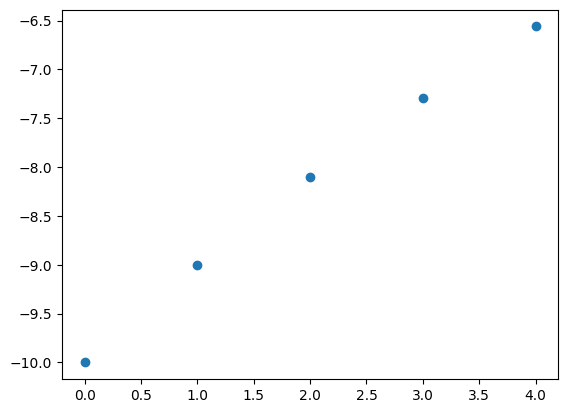

In [102]:
import numpy as np
import matplotlib.pyplot as plt

n=5
x = []
for i in range(n):
    x.append(i * n / n)

def f(x):
    return -10 * (.9 ** x)
y = []
for i in x:
    y.append(f(i))

plt.plot(x, np.array(y), "o")
plt.show()


In [108]:
def getMinimumTime(requestedServers, transitionTime):
    n = len(transitionTime)
    prefix = [0] * (n+1)
    for i in range(0, n):
        prefix[i+1] += prefix[i] + transitionTime[i]

    full_circle = prefix[n]
    current = 1
    path = 0
    for server in requestedServers:
        clockwise = prefix[server - 1] - prefix[current - 1]
        counter_clockwise = full_circle - abs(clockwise)

        path += min( abs(clockwise), counter_clockwise)
        current = server


    return path

requestedServers = [3, 2]
transitionTime = [2, 3, 1]

getMinimumTime(requestedServers, transitionTime)

4

In [111]:
#we create a dict and count frequencies if freq >= 2 we stop and return it!
def first_double(s):
    freq = {}
    for char in s:
        freq[char] = freq.get(char, 0) + 1
        if freq[char] == 2:
            return char
    return None
first_double("abcddart")

'd'

In [112]:
def first_double_int(nums):
    freq = {}
    for x in nums:
        freq[x] = freq.get(x, 0) + 1
        if freq[x] == 2:
            return True
    return False

In [121]:
def anagram(s, t):
    S = list(s)
    T = list(t)
    return S == T[ : : -1]
anagram("abcd", "dcba")

True

In [128]:
# nums > 0
def cont_subarray_pos(nums, k):
    n = len(nums)
    left = 0
    for right in range(n):
        while nums[left] + nums[right] != k and left < right:
            left += 1
        if nums[left] + nums[right] == k:
            return True
    return False

# nums < or >= 0
def cont_subarray(nums, k):
    n = len(nums)
    prefix = 0
    left = 0
    for right in range(n):
        prefix += nums[right]
        while prefix != k and left < right:
            prefix -= nums[left]
            left += 1
        if prefix == k:
            return True
    return False

def cont_subarray(nums, k):
    seen = set()
    prefix = 0
    for x in nums:
        prefix += x
        if prefix - k in seen:
            return True 
        seen.add(prefix)
    return False
nums = [3, 1, 4, 2, 5]
k = 6
cont_subarray(nums, k)

True

In [169]:
def product_ex(nums):
    n = len(nums)
    ans = [1] * n
    prefix = [1] * n
    suffix = [1] * n 
    for i in range(1, n):
        prefix[i] = prefix[i-1] * nums[i-1]
    for i in range(n-2, -1, -1):
        suffix[i] = suffix[i + 1] * nums[i+1]

    for i in range(n):
        ans[i] = prefix[i] * suffix[i]

    return ans
nums = [1, 2, 3, 4]
product_ex(nums)

[24, 12, 8, 6]

In [171]:
def binary_search(nums, target):
    left = 0
    right = len(nums) - 1
    while left <= right:
        mid = (left + right) // 2
        if target > nums[mid]:
            left = mid + 1
        elif target < nums[mid]:
            right = mid - 1
        else: 
            return mid

    return -1
nums = [-1, 0, 3, 5, 9, 12]
target = 9
binary_search(nums, target)

4

In [182]:
def binary_search_ins(nums, target):
    left = 0
    right = len(nums) - 1
    while left <= right:
        mid = (left + right) // 2
        if target > nums[mid]:
            left = mid + 1
        elif target < nums[mid]:
            right = mid - 1
        else: 
            return mid

    return right + 1

nums = [1, 3, 5, 6]
target = 4

binary_search_ins(nums, target)

2

In [189]:
def max_sum(nums):
    current = nums[0]
    best_sum = nums[0]
    for i in range(1, len(nums)):
        current = max(nums[i], current + nums[i])
        best_sum = max(best_sum, current)
    return best_sum
nums = [-2,1,-3,4,-1,2,1,-5,4]
max_sum(nums)

6

In [190]:
def max_profit(prices):
    min_price = float('inf')
    best_profit = 0
    for price in prices:
        min_price = min(min_price, price)
        profit = price - min_price
        best_profit = max(profit, best_profit)
    return best_profit



In [ ]:
def duplicates(nums):
    seen = set()
    for x in nums:
        if x not in seen:
            seen.add(x)
        else:
            return True
    return False

def valid(s):
    d = {')': '(', '}' : '{', ']': '['}
    stack = []
    for x in s:
        if x in '({[':
            stack.append(x)
        else:
            if len(stack) > 0 and stack[-1] == d[x]:
                stack.pop()
            else:
                return False
    return stack == []

def max_sum(nums):
    best_sum = -float('inf')
    current = 0
    for x in nums:
        current = max(x, x + current)
        best_sum = max(current, best_sum)
    return best_sum


6

In [ ]:
def best_time(prices):
    max_profit = 0
    min_price = prices[0]
    for price in prices:
        min_price = min(price, min_price)
        profit = price - min_price
        max_profit = max(profit, max_profit)
    return max_profit



def product_exc(nums):
    n = len(nums)
    prefix = [1] * n
    suffix = [1] * n
    ans = [1] * n

    for i in range(1, n):
        prefix[i] = prefix[i-1] * nums[i-1]
    
    for i in range(n-2, -1, -1):
        suffix[i] = suffix[i+1] * nums[i+1]

    for i in range(n):
        ans[i] = prefix[i] * suffix[i]

    return ans


def bin_search_ins(nums, target):
    left = 0
    right = len(nums) - 1
    while left <= right:
        mid = (left + right) // 2    
        if nums[mid] == target:
            return mid
        elif nums[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return left

1

In [ ]:
def long_consec(nums):
    set_nums = set(nums)
    max_count = 0
    for x in set_nums:
        count = 1
        while x + 1 in set_nums:
            count += 1           
            x = x + 1
        max_count = max(count, max_count)
    return max_count

def long_consec_seq(nums, k):
    count = 0
    prefix = 0
    freq = {0: 1}

    for x in nums:
        prefix += x
        count += freq.get(prefix - k, 0)
        freq[prefix] = freq.get(prefix, 0) + 1
    return count



1

In [ ]:
# PYTHON ASSESSMENT CHEAT SHEET

# 1. Looping
for i in range(n):
    pass

for i, x in enumerate(arr):
    pass

for x in arr:
    pass


# 2. Sorting
arr.sort()
arr.sort(reverse=True)
arr.sort(key=lambda x: x[0])

sorted_arr = sorted(arr)
sorted_by_second = sorted(pairs, key=lambda x: x[1])


# 3. Dictionary / Frequency Map
count = {}
for x in arr:
    count[x] = count.get(x, 0) + 1


# 4. Set
seen = set()
for x in arr:
    if x in seen:
        return True
    seen.add(x)


# 5. Stack
stack = []
stack.append(x)
stack.pop()
top = stack[-1]


# 6. Queue
from collections import deque
q = deque()
q.append(x)
q.popleft()


# 7. Prefix Sum
prefix = [0] * (n + 1)
for i in range(n):
    prefix[i + 1] = prefix[i] + nums[i]

# sum of nums[l:r+1]
sub_sum = prefix[r + 1] - prefix[l]


# 8. Running Prefix Sum
prefix = 0
for x in nums:
    prefix += x


# 9. Binary Search
def binary_search(nums, target):
    left = 0
    right = len(nums) - 1

    while left <= right:
        mid = (left + right) // 2

        if nums[mid] == target:
            return mid
        elif nums[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return -1


# 10. Search Insert Position
def search_insert(nums, target):
    left = 0
    right = len(nums) - 1

    while left <= right:
        mid = (left + right) // 2

        if nums[mid] == target:
            return mid
        elif nums[mid] < target:
            left = mid + 1
        else:
            right = mid - 1

    return left


# 11. Two Sum
def two_sum(nums, target):
    seen = {}

    for i, x in enumerate(nums):
        need = target - x
        if need in seen:
            return [seen[need], i]
        seen[x] = i


# 12. Sliding Window
left = 0
for right in range(len(arr)):
    while bad_condition:
        left += 1


# 13. Longest Substring Without Repeating Characters
def longest_substring(s):
    freq = {}
    left = 0
    best = 0

    for right, char in enumerate(s):
        freq[char] = freq.get(char, 0) + 1

        while freq[char] > 1:
            freq[s[left]] -= 1
            left += 1

        best = max(best, right - left + 1)

    return best


# 14. Kadane's Algorithm
def max_subarray(nums):
    current = nums[0]
    best = nums[0]

    for x in nums[1:]:
        current = max(x, current + x)
        best = max(best, current)

    return best


# 15. Best Time to Buy and Sell Stock
def max_profit(prices):
    min_price = float('inf')
    best_profit = 0

    for price in prices:
        min_price = min(min_price, price)
        best_profit = max(best_profit, price - min_price)

    return best_profit


# 16. Product of Array Except Self
def product_except_self(nums):
    n = len(nums)
    prefix = [1] * n
    suffix = [1] * n
    ans = [1] * n

    for i in range(1, n):
        prefix[i] = prefix[i - 1] * nums[i - 1]

    for i in range(n - 2, -1, -1):
        suffix[i] = suffix[i + 1] * nums[i + 1]

    for i in range(n):
        ans[i] = prefix[i] * suffix[i]

    return ans


# 17. Valid Parentheses
def is_valid(s):
    d = {')': '(', '}': '{', ']': '['}
    stack = []

    for char in s:
        if char in '({[':
            stack.append(char)
        else:
            if not stack or stack[-1] != d[char]:
                return False
            stack.pop()

    return not stack


# 18. Subarray Sum Equals K
def subarray_sum(nums, k):
    count = 0
    prefix = 0
    freq = {0: 1}

    for x in nums:
        prefix += x
        count += freq.get(prefix - k, 0)
        freq[prefix] = freq.get(prefix, 0) + 1

    return count


# 19. Merge Intervals
def merge_intervals(intervals):
    if not intervals:
        return []

    intervals.sort(key=lambda x: x[0])
    merged = [intervals[0]]

    for start, end in intervals[1:]:
        if start <= merged[-1][1]:
            merged[-1][1] = max(merged[-1][1], end)
        else:
            merged.append([start, end])

    return merged


# 20. Longest Consecutive Sequence
def longest_consecutive(nums):
    s = set(nums)
    best = 0

    for x in s:
        if x - 1 not in s:
            length = 1
            while x + length in s:
                length += 1
            best = max(best, length)

    return best


In [227]:
def smallest_subarray(nums, k):
    left = 0
    current_sum = 0
    length = len(nums)

    for right in range(len(nums)):
        current_sum += nums[right]
        while current_sum >= k:
            length = min(length, right - left + 1)
            current_sum -= nums[left]
            left += 1
        
    return length

smallest_subarray([2, 3, 1, 2, 4, 3], 10)

4

In [228]:
def longestAlternatingFlip(s):
    def best_for_pattern(start_bit):
        left = 0
        mismatches = 0
        best = 0

        for right in range(len(s)):
            expected = '01'[(start_bit + right) & 1]
            if s[right] != expected:
                mismatches += 1

            while mismatches > 1:
                expected_left = '01'[(start_bit + left) & 1]
                if s[left] != expected_left:
                    mismatches -= 1
                left += 1

            best = max(best, right - left + 1)

        return best

    return max(best_for_pattern(0), best_for_pattern(1))

longestAlternatingFlip("111101")

5

In [241]:
expected = [(0 + 12) & 1]
expected

[0]